# Friedkin–Johnsen Baseline (Pure Coefficient Form)

Pure baseline FJ uses only initial opinions $x_0$, social matrix $W$, and stubbornness coefficient $\lambda$.

In [7]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
ROOT = Path('/home/sammli/llm-network')
CLEAN = ROOT / 'modeling' / 'cleaned_data'
RUN_DIRS = sorted([p for p in CLEAN.glob('run_*') if p.is_dir()])
assert RUN_DIRS, f'No run_* folders in {CLEAN}'

PARAMS = {
    'lambda_grid': [0.2, 0.4, 0.6, 0.8],
}

print('Pure baseline mode: FJ update uses only lambda and neighbor opinions.')

def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def numeric_agent_key(agent_id: str):
    if isinstance(agent_id, str) and agent_id.startswith('agent_'):
        tail = agent_id.split('_')[-1]
        if tail.isdigit():
            return int(tail)
    return 10**9

def parse_agent_id(v):
    if isinstance(v, str) and v.startswith('agent_'):
        return v
    if isinstance(v, int):
        return f'agent_{v}'
    return None

def to_int_list(values):
    out = []
    if not isinstance(values, list):
        return out
    for x in values:
        try:
            out.append(int(x))
        except Exception:
            continue
    return out

def build_events_from_per_agent(run_dir: Path):
    events = []
    obs_seq_by_agent = defaultdict(list)
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return events, obs_seq_by_agent
    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        target = fp.stem
        for row in load_jsonl(fp):
            topo = row.get('topology_profile_for_agent', {}) or {}
            ss = topo.get('ss', None)
            msg_index = row.get('message_index', None)
            if ss is None or msg_index is None:
                continue
            rec_indices = to_int_list(row.get('recommendation_indices'))
            if not rec_indices:
                rec_indices = to_int_list(row.get('used_indices'))
            sender = parse_agent_id(row.get('influenced_by'))
            events.append({'t': int(msg_index), 'target': target, 'sender': sender, 'obs_ss': float(ss), 'rec_indices': rec_indices})
            obs_seq_by_agent[target].append(float(ss))
    events.sort(key=lambda e: (e['t'], numeric_agent_key(e['target'])))
    return events, obs_seq_by_agent

def build_message_lookup(run_dir: Path):
    lookup = {}
    messages = load_jsonl(run_dir / 'messages_with_alignment.jsonl')
    for m in messages:
        idx = m.get('index', None)
        if idx is None:
            continue
        try:
            k = int(idx)
        except Exception:
            continue
        lookup[k] = {'sender': parse_agent_id(m.get('sender_id'))}
    return lookup

def get_graph_adjacency(graph):
    if isinstance(graph, dict) and 'edges' in graph:
        adj = defaultdict(list)
        for src, dst in graph.get('edges', []):
            s = parse_agent_id(src)
            d = parse_agent_id(dst)
            if s and d:
                adj[s].append(d)
        return dict(adj)
    if isinstance(graph, dict):
        return {k: list(v) for k, v in graph.items() if isinstance(v, list)}
    return {}

def obs_count(run_dir: Path):
    events, _ = build_events_from_per_agent(run_dir)
    return len(events)

RUN_DIR = max(RUN_DIRS, key=obs_count)
print('Using run:', RUN_DIR.name, 'event_obs=', obs_count(RUN_DIR))

def load_run_data(run_dir: Path):
    graph_raw = load_json(run_dir / 'connection_graph.json')
    graph = get_graph_adjacency(graph_raw)
    events, obs_seq_by_agent = build_events_from_per_agent(run_dir)
    message_lookup = build_message_lookup(run_dir)
    agent_ids = set(graph.keys())
    for src, dsts in graph.items():
        agent_ids.add(src)
        agent_ids.update(dsts)
    for ev in events:
        agent_ids.add(ev['target'])
        if ev['sender'] is not None:
            agent_ids.add(ev['sender'])
    for m in message_lookup.values():
        if m['sender'] is not None:
            agent_ids.add(m['sender'])
    agent_ids = sorted(agent_ids, key=numeric_agent_key)
    return {'graph': graph, 'events': events, 'obs_seq_by_agent': obs_seq_by_agent, 'agent_ids': agent_ids, 'message_lookup': message_lookup}

def build_predecessors(graph, agent_ids):
    preds = {a: [] for a in agent_ids}
    for src, dsts in graph.items():
        for dst in dsts:
            if dst in preds:
                preds[dst].append(src)
    return preds

def initial_opinions(obs_seq_by_agent, agent_ids):
    x0 = {a: 0.0 for a in agent_ids}
    for a in agent_ids:
        seq = obs_seq_by_agent.get(a, [])
        if seq:
            x0[a] = float(seq[0])
    return x0

def evaluate(records):
    if not records:
        return {'mae': np.nan, 'rmse': np.nan}
    d = np.array([r['pred'] - r['obs'] for r in records], dtype=float)
    return {'mae': float(np.mean(np.abs(d))), 'rmse': float(np.sqrt(np.mean(d * d)))}

Pure baseline mode: FJ update uses only lambda and neighbor opinions.
Using run: run_20260217-185316 event_obs= 4777


In [9]:
def build_W_for_fj(preds, agent_ids):
    n = len(agent_ids)
    idx = {a: i for i, a in enumerate(agent_ids)}
    W = np.zeros((n, n), dtype=float)
    for dst in agent_ids:
        j = idx[dst]
        p = preds.get(dst, [])
        if p:
            w = 1.0 / len(p)
            for src in p:
                if src in idx:
                    W[j, idx[src]] = w
        else:
            W[j, j] = 1.0
    return W, idx

def run_event_fj(data, lam=0.6):
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    x0 = initial_opinions(data['obs_seq_by_agent'], agent_ids)
    x = dict(x0)
    records = []
    for ev in data['events']:
        target = ev['target']
        candidates = []

        for msg_idx in ev['rec_indices']:
            meta = data['message_lookup'].get(msg_idx)
            if not meta:
                continue
            sender = meta['sender']
            if sender is None or sender not in x or sender == target:
                continue
            if sender not in preds.get(target, []):
                continue
            candidates.append(sender)

        if not candidates:
            sender = ev['sender']
            if sender in x and sender != target and sender in preds.get(target, []):
                candidates.append(sender)

        if candidates:
            social = float(np.mean([x[s] for s in candidates]))
        else:
            social = x[target]

        x[target] = lam * x0[target] + (1.0 - lam) * social
        records.append({'t': ev['t'], 'agent': target, 'pred': float(x[target]), 'obs': float(ev['obs_ss'])})
    return x, records, x0

In [10]:
data = load_run_data(RUN_DIR)
print('agents=', len(data['agent_ids']), 'events=', len(data['events']))
lambdas = PARAMS['lambda_grid']
rows = []
for lam in lambdas:
    _, rec, _ = run_event_fj(data, lam=lam)
    m = evaluate(rec)
    rows.append({'lambda': lam, 'n_eval': len(rec), **m})
res = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)
res.head(10)

agents= 30 events= 4777


,lambda,n_eval,mae,rmse
0,0.2,4777,0.244783,0.253236
1,0.4,4777,0.244487,0.253488
2,0.6,4777,0.244083,0.253906
3,0.8,4777,0.243708,0.254668


Best: {'lambda': 0.2, 'n_eval': 4777.0, 'mae': 0.24478271539020618, 'rmse': 0.2532363959747999}
Metrics: {'mae': 0.24478271539020618, 'rmse': 0.2532363959747999}
Using constant lambda = 0.2


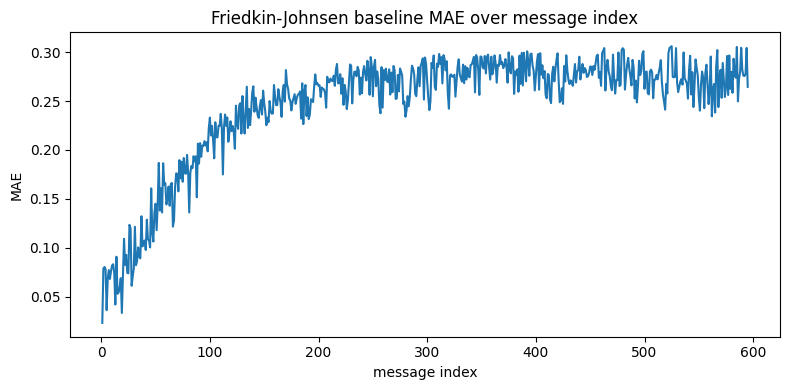

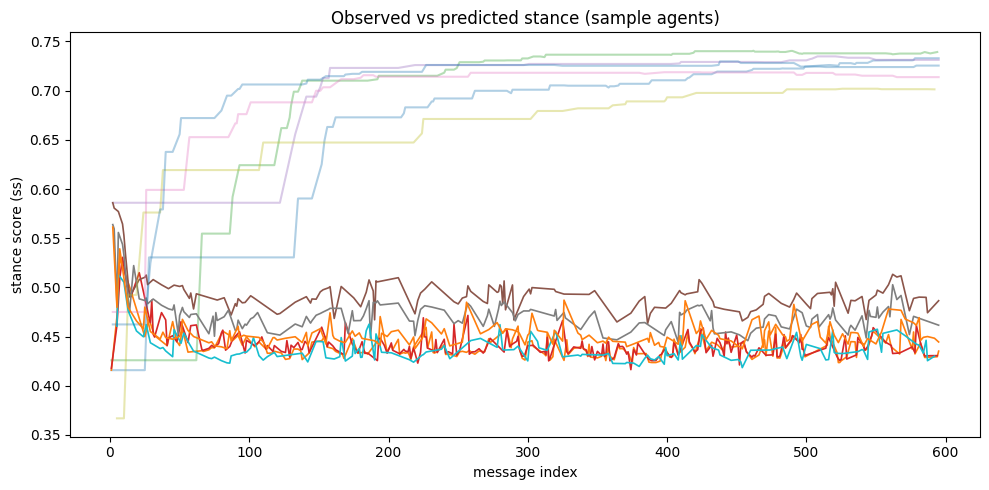

In [ ]:
best = res.iloc[0].to_dict()
print('Best:', best)
_, rec, x0 = run_event_fj(data, lam=float(best['lambda']))
met = evaluate(rec)
print('Metrics:', met)
print('Using constant lambda =', float(best['lambda']))
df = pd.DataFrame(rec)
df['abs_err'] = (df['pred'] - df['obs']).abs()
err_t = df.groupby('t', as_index=False)['abs_err'].mean()
plt.figure(figsize=(8, 4))
plt.plot(err_t['t'], err_t['abs_err'])
plt.title('Friedkin-Johnsen baseline MAE over message index')
plt.xlabel('message index')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()
sample_agents = sorted(df['agent'].unique(), key=numeric_agent_key)[:30]
plt.figure(figsize=(10, 5))
for a in sample_agents:
    dfa = df[df['agent'] == a]
    plt.plot(dfa['t'], dfa['obs'], alpha=0.35)
    plt.plot(dfa['t'], dfa['pred'], linewidth=1.2)
plt.title('Observed vs predicted stance (sample agents)')
plt.xlabel('message index')
plt.ylabel('stance score (ss)')
plt.tight_layout()
plt.show()

## Matrix Representation and How to Read the Eigenvalue Plot

For constant $\lambda$, the baseline FJ map is:
$$x(t+1)=\lambda x_0 + (1-\lambda)Wx(t)$$

Set $A=(1-\lambda)W$. Then:
$$x^*=(I-A)^{-1}\lambda x_0 \quad \text{if } \rho(A)<1.$$ 

Interpretation of the spectrum plot of $A$:
- If all eigenvalues satisfy $|\lambda_i|<1$, repeated updates contract to a unique fixed point.
- The spectral radius $\rho(A)=\max_i |\lambda_i|$ determines stability margin.
- Values of $\rho(A)$ closer to 1 imply slower convergence.
- Complex eigenvalues indicate oscillatory transients.

spectral radius rho(A)= 0.8000000000000009
Fixed point exists and is unique. First 10 components: [0.43875195 0.44210612 0.48624194 0.46682332 0.43243217 0.45217815
 0.45302121 0.45613902 0.44532499 0.46538061]


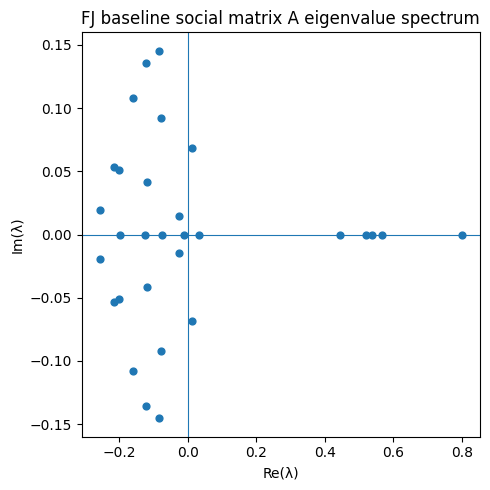

In [12]:
preds = build_predecessors(data['graph'], data['agent_ids'])
W, idx = build_W_for_fj(preds, data['agent_ids'])
lam = float(best['lambda'])
_, _, x0 = run_event_fj(data, lam=lam)
x0_vec = np.array([x0[a] for a in data['agent_ids']], dtype=float)
L = lam * np.eye(len(data['agent_ids']))
A = (np.eye(len(data['agent_ids'])) - L) @ W
vals, _ = np.linalg.eig(A)
rad = float(np.max(np.abs(vals)))
print('spectral radius rho(A)=', rad)
if rad < 1.0:
    x_star = np.linalg.solve(np.eye(len(data['agent_ids'])) - A, L @ x0_vec)
    print('Fixed point exists and is unique. First 10 components:', x_star[:10])
else:
    print('rho(A) >= 1; fixed-point stability condition not satisfied globally.')
plt.figure(figsize=(5, 5))
plt.scatter(np.real(vals), np.imag(vals), s=24)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title('FJ baseline social matrix A eigenvalue spectrum')
plt.xlabel('Re(λ)')
plt.ylabel('Im(λ)')
plt.tight_layout()
plt.show()